In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("../data/spotify_tracks_cleaned.csv")
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


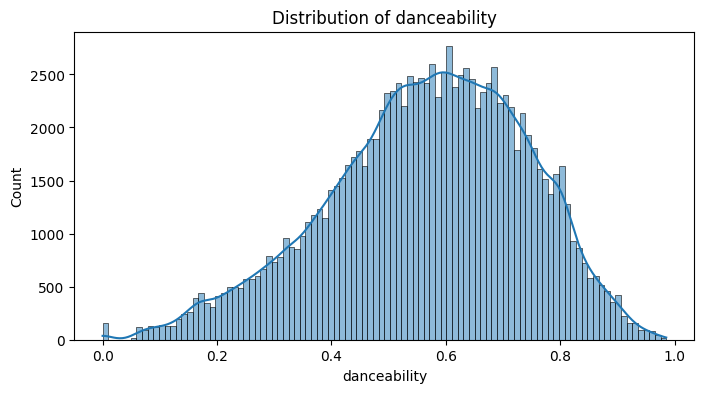

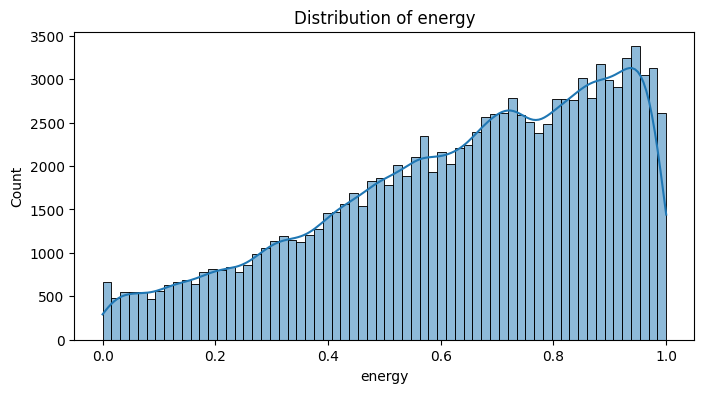

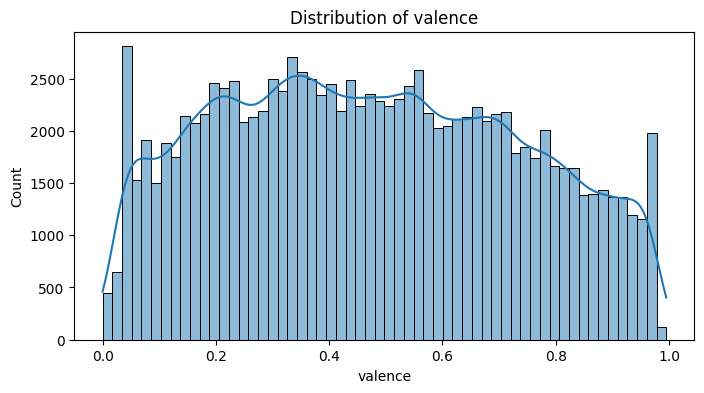

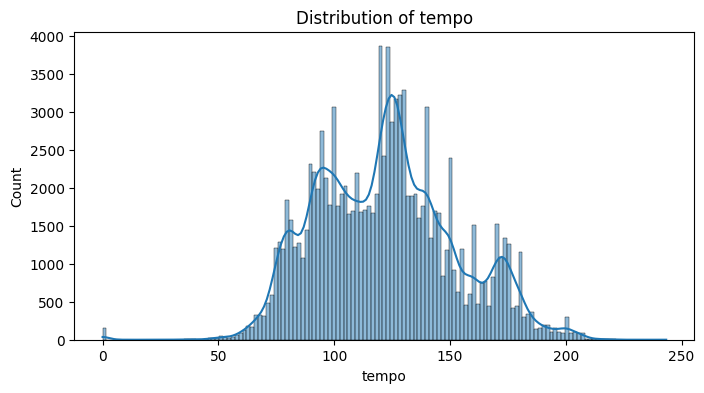

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns for distribution plots
cols = ["danceability", "energy", "valence", "tempo"]

for col in cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

The dataset shows moderate-high danceability, mostly high energy tracks, wide valence spread indicating mixed emotional tone, and tempo centered around ~120 BPM suggesting mainstream rhythm dominance.


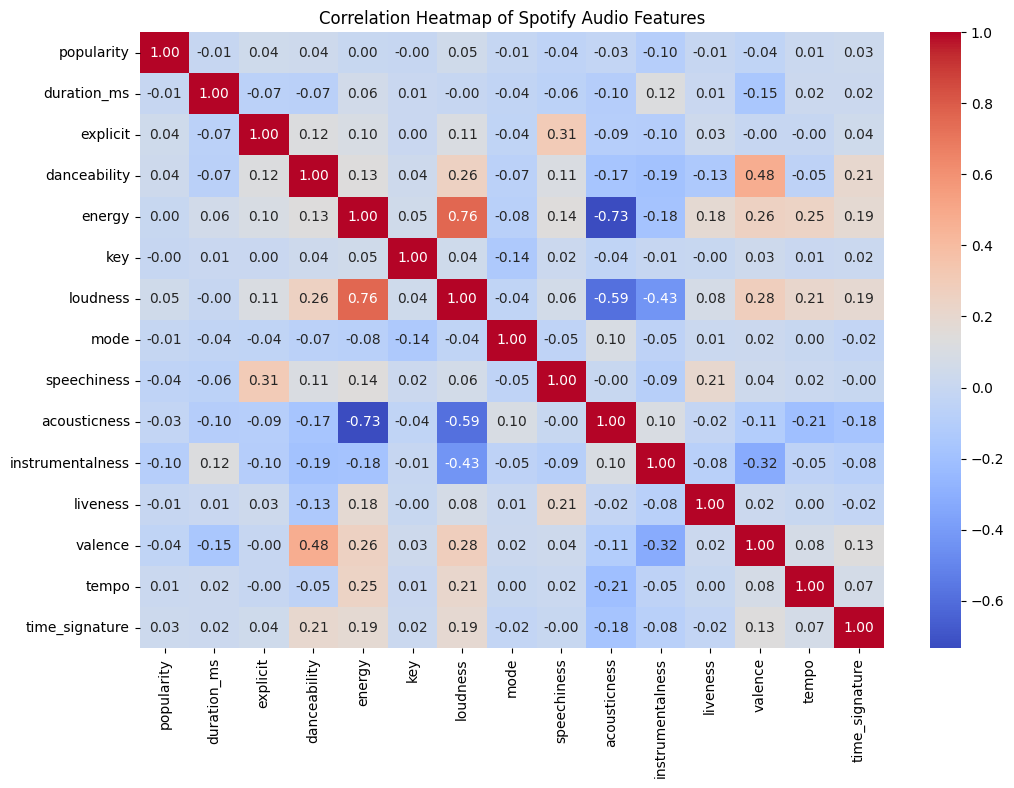

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Spotify Audio Features")
plt.show()

The correlation heatmap shows strong positive correlation between energy and loudness, while acousticness is strongly negatively correlated with energy and loudness. Danceability and valence show moderate positive correlation, suggesting happier tracks are more dance-friendly. Popularity shows weak correlation with most audio features, indicating it is influenced by factors beyond audio properties.

## #Feature Selection

In [20]:
# features: your selected audio features
features = df[['danceability', 'energy', 'valence', 'acousticness',
               'instrumentalness', 'speechiness', 'liveness', 'tempo']]

# scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# apply KMeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_features)

# assign cluster labels
df['cluster'] = kmeans.labels_

# check clusters with features only
print(df.head())

   popularity  duration_ms  explicit  danceability  energy  key  loudness  \
0          73       230666         0         0.676  0.4610    1    -6.746   
1          55       149610         0         0.420  0.1660    1   -17.235   
2          57       210826         0         0.438  0.3590    0    -9.734   
3          71       201933         0         0.266  0.0596    0   -18.515   
4          82       198853         0         0.618  0.4430    2    -9.681   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     0       0.1430        0.0322          0.000001    0.3580    0.715   
1     1       0.0763        0.9240          0.000006    0.1010    0.267   
2     1       0.0557        0.2100          0.000000    0.1170    0.120   
3     1       0.0363        0.9050          0.000071    0.1320    0.143   
4     1       0.0526        0.4690          0.000000    0.0829    0.167   

     tempo  time_signature  cluster  
0   87.917               4        2  
1   77.489

In [21]:
# groupby is a method used to split a dataset into groups based on some criteria.
print(df.groupby('cluster').mean())

         popularity    duration_ms  explicit  danceability    energy  \
cluster                                                                
0         34.942706  235429.768460  0.121492      0.468906  0.818535   
1         34.119995  220311.330863  0.036937      0.517259  0.383723   
2         33.581122  214119.742365  0.118172      0.687803  0.725152   
3         29.740236  220809.573547  0.003442      0.368862  0.194339   
4         28.621678  281684.305399  0.040947      0.578384  0.762279   

              key   loudness      mode  speechiness  acousticness  \
cluster                                                             
0        5.337160  -5.779807  0.636688     0.125831      0.135980   
1        5.088093 -10.550804  0.728631     0.052372      0.664577   
2        5.436372  -6.418685  0.608773     0.087238      0.193056   
3        4.911294 -19.848435  0.646366     0.051902      0.855223   
4        5.498837  -8.312362  0.548754     0.071384      0.085514   

         in

# # Scaling + KMeans Clustering

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
df = pd.read_csv("../data/spotify_tracks_cleaned.csv") 
print(df.shape) #shape: row, col
df.head() # first 5 sets instead of whole

(114000, 15)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


In [24]:
feature_cols = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo"
]

X = df[feature_cols] # X is now a new df with only the above taken sagle feature cols
print(X.head())

   danceability  energy  valence  acousticness  instrumentalness  speechiness  \
0         0.676  0.4610    0.715        0.0322          0.000001       0.1430   
1         0.420  0.1660    0.267        0.9240          0.000006       0.0763   
2         0.438  0.3590    0.120        0.2100          0.000000       0.0557   
3         0.266  0.0596    0.143        0.9050          0.000071       0.0363   
4         0.618  0.4430    0.167        0.4690          0.000000       0.0526   

   liveness    tempo  
0    0.3580   87.917  
1    0.1010   77.489  
2    0.1170   76.332  
3    0.1320  181.740  
4    0.0829  119.949  


In [25]:
# #X madhe kiti null values aahe tyancha sum sanga, pratyek col madhe. T & F it does internally but returns 0,1,2... due to some
print(X.isnull().sum()) 

danceability        0
energy              0
valence             0
acousticness        0
instrumentalness    0
speechiness         0
liveness            0
tempo               0
dtype: int64


In [26]:
# As tempo is of bigger numbers, we need to transform/standardize it.
#Here all became like a numpy arr... no col names anymore
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df.describe()

,danceability,energy,valence,acousticness,instrumentalness,speechiness,liveness,tempo
count,1.140000e+05,1.140000e+05,1.140000e+05,1.140000e+05,1.140000e+05,1.140000e+05,1.140000e+05,1.140000e+05
mean,4.068792e-16,-2.114176e-16,1.595605e-16,-9.573628e-17,-1.595605e-17,7.978024e-18,1.136868e-16,-4.986265e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-3.266080e+00,-2.549946e+00,-1.828544e+00,-9.470374e-01,-5.041119e-01,-8.006298e-01,-1.121737e+00,-4.074574e+00
25%,-6.384647e-01,-6.734152e-01,-8.256896e-01,-8.962136e-01,-5.041119e-01,-4.610918e-01,-6.069689e-01,-7.648621e-01
50%,7.606216e-02,1.734091e-01,-3.883451e-02,-4.387992e-01,-5.039775e-01,-3.381393e-01,-4.283758e-01,-4.364434e-03
75%,7.387282e-01,8.453026e-01,8.058776e-01,8.513439e-01,-3.458194e-01,-1.438660e-03,3.122604e-01,5.978759e-01
max,2.409799e+00,1.425755e+00,2.009303e+00,2.048260e+00,2.726348e+00,8.326228e+00,4.131002e+00,4.043762e+00


WHAT WE DID ABOVE:
it was shifted to numpy arr so that numerics like the tempo's numbers can be transformed into standardized col.. for computation sake we did for this. And we shifted it back to df for us to see that again (readable).

NOTE:
Why did the data become a NumPy array after scaling?

When we apply StandardScaler, the function fit_transform() returns the scaled values as a NumPy array because Scikit-learn is designed to work mainly with NumPy for faster mathematical computations.

Scaling is important because different features have different ranges (for example, tempo can be 60–200 while features like energy are between 0 and 1). Without scaling, large-range features like tempo would dominate the clustering process.

So, scaling transforms all numeric values into a common standardized scale (mean ≈ 0 and standard deviation ≈ 1), making them comparable and suitable for algorithms like KMeans.

We then convert the NumPy array back into a Pandas DataFrame only for readability and analysis (so we can view column names, use .describe(), and interpret the scaled data easily).

# #K MEANS

In [28]:
#It tells you how far songs are from their cluster center- inertia.
inertia_values = []

k_range = range(3, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

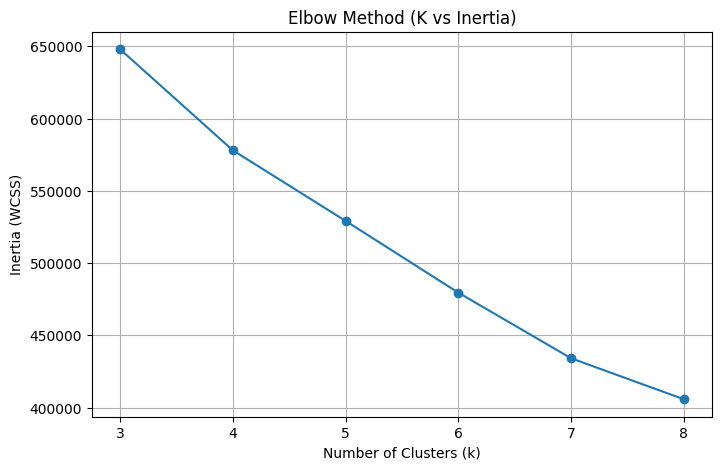

In [29]:
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_values, marker="o")
plt.title("Elbow Method (K vs Inertia)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)
plt.show()

In [30]:
# Above it feels best k=4, cuz the curve bends like a sharp drop then becomes flatter.

In [31]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np

# Random sample of 5000 points
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), size=5000, replace=False)
sample_scaled = X_scaled[sample_indices]

silhouette_scores = []

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_scaled)
    score = silhouette_score(sample_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.18656496070721432, 0.19096700295097152, 0.2036301519424283, 0.2037224162052515, 0.21415146507008112, 0.19498728263545323]


In [32]:
# Picking highest from the silhouette score= 7
best_k = 7

In [33]:
from sklearn.cluster import KMeans

best_k = 7   # or 4 if you choose elbow

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [34]:
df["cluster"] = cluster_labels
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,5
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,1
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,1
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,1
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,1


# #NOW WE HAVE CLUSTER COLUMN

In [35]:
# ANALYZING THE CLUSTER
cluster_summary = df.groupby("cluster")[feature_cols].mean()
print(cluster_summary)

         danceability    energy   valence  acousticness  instrumentalness  \
cluster                                                                     
0            0.585570  0.757270  0.338454      0.088463          0.786379   
1            0.520349  0.372103  0.376548      0.692899          0.020667   
2            0.367677  0.189541  0.203960      0.856923          0.843823   
3            0.473881  0.807849  0.371552      0.073351          0.031414   
4            0.519497  0.748116  0.507470      0.290408          0.070106   
5            0.705146  0.716016  0.695650      0.213458          0.019084   
6            0.575431  0.669989  0.446394      0.717210          0.010766   

         speechiness  liveness       tempo  
cluster                                     
0           0.072118  0.172209  127.702535  
1           0.051409  0.156332  112.314661  
2           0.051172  0.152683  103.762211  
3           0.082771  0.190941  139.723268  
4           0.086623  0.737977  123.

In [36]:
# Counting songs in each cluster
print(df["cluster"].value_counts())

cluster
5    37124
3    26561
1    22450
0    11403
4     7916
2     7405
6     1141
Name: count, dtype: int64


In [37]:
df.to_csv("../data/spotify_tracks_clustered.csv", index=False)
print("Saved successfully!")

Saved successfully!


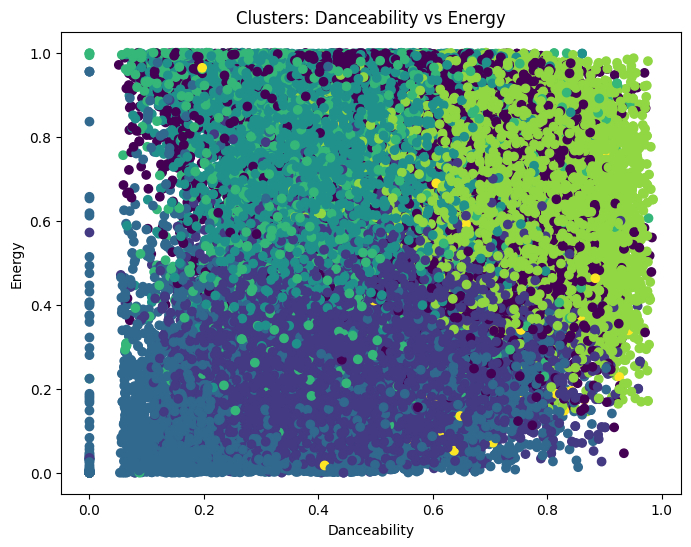

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(df["danceability"], df["energy"], c=df["cluster"])
plt.title("Clusters: Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()